<a href="https://colab.research.google.com/github/RajShekhar0341/DataScience/blob/main/7_NaiveBayesClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
data = pd.read_csv("/content/synthetic_text_data.csv")

In [ ]:
print(data.head())

                                                text          label
0  Artificial intelligence is advancing in health...     Technology
1  Football fans are excited about the upcoming W...         Sports
2  New policies regarding climate change have spa...       Politics
3  The latest blockbuster movie has shattered box...  Entertainment
4  Quantum computing promises to revolutionize in...     Technology


In [ ]:
x = data["text"]
y = data["label"]
print(data)

                                                 text          label
0   Artificial intelligence is advancing in health...     Technology
1   Football fans are excited about the upcoming W...         Sports
2   New policies regarding climate change have spa...       Politics
3   The latest blockbuster movie has shattered box...  Entertainment
4   Quantum computing promises to revolutionize in...     Technology
..                                                ...            ...
80  AI is enhancing customer experiences in retail...     Technology
81  Politicians are debating the pros and cons of ...       Politics
82  Television networks are trying to adapt to the...  Entertainment
83  New wearable technologies are improving health...     Technology
84  Local sports leagues are organizing tournament...         Sports

[85 rows x 2 columns]


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
vectorizer = CountVectorizer()
x_train_vectorizer = vectorizer.fit_transform(x_train)
x_test_vectorized = vectorizer.transform(x_test)

In [ ]:
model = MultinomialNB()
model.fit(x_train_vectorizer, y_train)

MultinomialNB()

In [ ]:
y_pred = model.predict(x_test_vectorized)

Accuracy: 88.23529411764706%


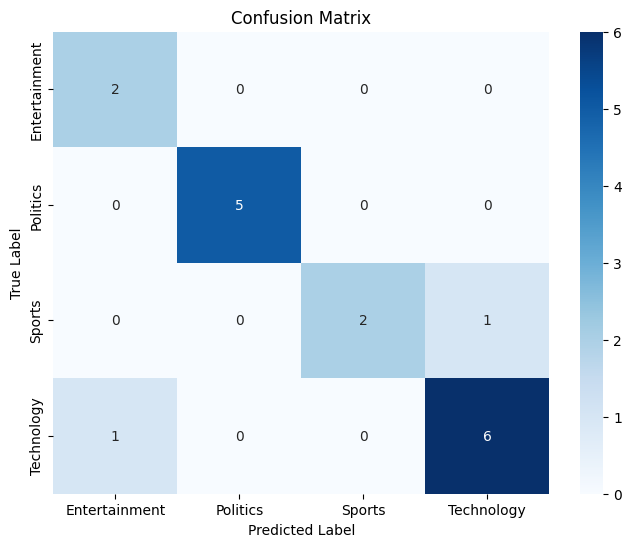

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(f'Accuracy: {accuracy *100}%')
class_labels = np.unique(y_test)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()